This file contains code written by me and by Claude Code.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import DBSCAN
import matplotlib as mpl
from astropy import units as u
import time
from scipy.sparse.linalg import eigsh
from scipy.stats import binned_statistic, binned_statistic_2d

In [35]:
from astropy.io import fits

# Read the FITS file
# hdu_list = fits.open("../LRG-Y1-comoving-complete.fits")
hdu_list = fits.open("../BGS-Y1-comoving-complete.fits")

# Print info about the file structure
hdu_list.info()

# Access the data (usually in the first extension for tables)
data = hdu_list[1].data

# Print column names
print("\nColumn names:")
print(data.columns.names)

# Print first few rows
print("\nFirst 5 rows:")
print(data[:5])

# Close the file
hdu_list.close()

Filename: ../BGS-Y1-comoving-complete.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  LSS           1 BinTableHDU     24   104306R x 7C   [K, K, D, D, D, D, 3E]   

Column names:
['TARGETID', 'TILEID', 'Z', 'RA', 'DEC', 'WEIGHT', 'comoving_mpc-h']

First 5 rows:
[(39627558764939109, 24682, 0.27098375, 159.05958502, -9.41625383, 1.        , [-702.98    ,  269.01028 , -124.82697 ])
 (39627558777523973, 20259, 0.26949346, 159.95655333, -9.46235588, 1.        , [-703.3796  ,  256.61343 , -124.788414])
 (39627558781717062, 23401, 0.26864585, 160.12957108, -9.4766092 , 1.00002778, [-702.0535  ,  253.73009 , -124.60753 ])
 (39627558806886202, 23401, 0.26978775, 161.76505312, -9.40271676, 1.        , [-711.9759  ,  234.56708 , -124.135445])
 (39627558819466315, 23401, 0.2657477 , 162.44551631, -9.56941496, 1.        , [-704.3645  ,  222.82187 , -124.54774 ])]


In [36]:
# Get comoving positions
positions = data['comoving_mpc-h']

# Print the range of each coordinate
for i in range(3):
    print(f"Axis {i}: min = {np.min(positions[:, i]):.2f}, max = {np.max(positions[:, i]):.2f}, range = {np.max(positions[:, i]) - np.min(positions[:, i]):.2f}")

Axis 0: min = -1000.00, max = -700.00, range = 299.99
Axis 1: min = -399.99, max = 399.96, range = 799.95
Axis 2: min = -125.00, max = 100.00, range = 225.00


In [38]:
# Select a 300 Mpc/h box subset with a buffer to avoid edge effects
box_size_x = 250  # Mpc/h
box_size_y = 750  # Mpc/h
box_size_z = 200  # Mpc/h
buffer_size = 10  # Mpc/h (same as neighborhood radius)

# Find a good center point (middle of the data range)
x_center = (np.min(positions[:, 0]) + np.max(positions[:, 0])) / 2
y_center = (np.min(positions[:, 1]) + np.max(positions[:, 1])) / 2
z_center = (np.min(positions[:, 2]) + np.max(positions[:, 2])) / 2

print(f"Box center: ({x_center:.2f}, {y_center:.2f}, {z_center:.2f})")

# Select galaxies within the inner box (these are the ones we want embeddings for)
half_box_x = box_size_x / 2
half_box_y = box_size_y / 2
half_box_z = box_size_z / 2
inner_mask = (
    (positions[:, 0] >= x_center - half_box_x) & (positions[:, 0] < x_center + half_box_x) &
    (positions[:, 1] >= y_center - half_box_y) & (positions[:, 1] < y_center + half_box_y) &
    (positions[:, 2] >= z_center - half_box_z) & (positions[:, 2] < z_center + half_box_z)
)

# Select galaxies within the outer box (inner box + buffer for distance calculations)
half_box_with_buffer_x = half_box_x + buffer_size  # assuming cubic box for simplicity
half_box_with_buffer_y = half_box_y + buffer_size
half_box_with_buffer_z = half_box_z + buffer_size

outer_mask = (
    (positions[:, 0] >= x_center - half_box_with_buffer_x) & (positions[:, 0] < x_center + half_box_with_buffer_x) &
    (positions[:, 1] >= y_center - half_box_with_buffer_y) & (positions[:, 1] < y_center + half_box_with_buffer_y) &
    (positions[:, 2] >= z_center - half_box_with_buffer_z) & (positions[:, 2] < z_center + half_box_with_buffer_z)
)

# Get positions for both regions
inner_positions = positions[inner_mask]
outer_positions = positions[outer_mask]

# Create a mask to identify which galaxies in outer_positions are in the inner box
# (we'll use this later to extract only the inner embeddings)
inner_indices_in_outer = np.where(
    (outer_positions[:, 0] >= x_center - half_box_x) & (outer_positions[:, 0] < x_center + half_box_x) &
    (outer_positions[:, 1] >= y_center - half_box_y) & (outer_positions[:, 1] < y_center + half_box_y) &
    (outer_positions[:, 2] >= z_center - half_box_z) & (outer_positions[:, 2] < z_center + half_box_z)
)[0]

print(f"Inner box: {len(inner_positions)} galaxies")
print(f"Outer box (with {buffer_size} Mpc/h buffer): {len(outer_positions)} galaxies")
print(f"Buffer galaxies: {len(outer_positions) - len(inner_positions)}")

Box center: (-850.00, -0.01, -12.50)
Inner box: 76726 galaxies
Outer box (with 10 Mpc/h buffer): 90300 galaxies
Buffer galaxies: 13574


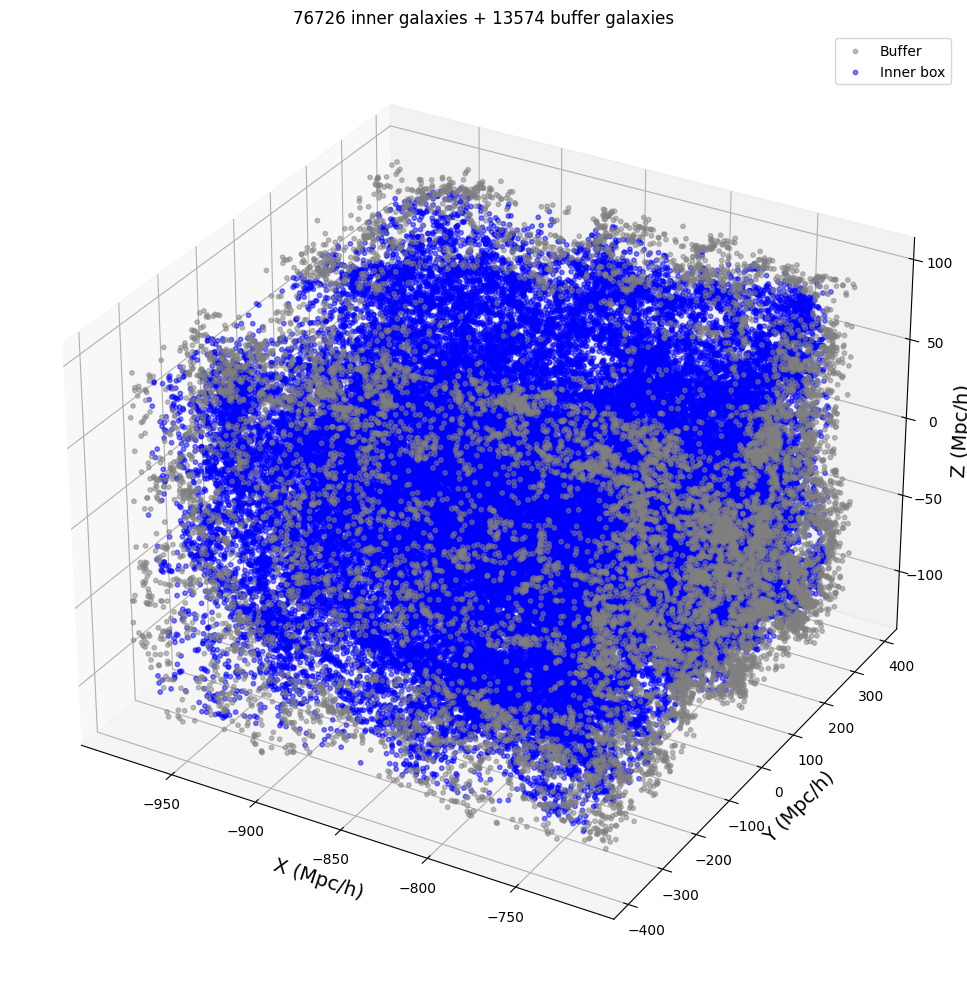

In [39]:
# Visualize the selected regions
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Plot buffer galaxies in grey
buffer_mask = np.ones(len(outer_positions), dtype=bool)
buffer_mask[inner_indices_in_outer] = False
ax.scatter(outer_positions[buffer_mask, 0], outer_positions[buffer_mask, 1], 
           outer_positions[buffer_mask, 2], alpha=0.5, s=10, c='grey', label='Buffer')

# Plot inner galaxies in blue
ax.scatter(inner_positions[:, 0], inner_positions[:, 1], inner_positions[:, 2], 
           alpha=0.5, s=10, c='blue', label='Inner box')

ax.set_xlabel('X (Mpc/h)', fontsize=14)
ax.set_ylabel('Y (Mpc/h)', fontsize=14)
ax.set_zlabel('Z (Mpc/h)', fontsize=14)
ax.set_title(f'{len(inner_positions)} inner galaxies + {len(outer_positions) - len(inner_positions)} buffer galaxies')
ax.legend()
plt.tight_layout()
plt.show()

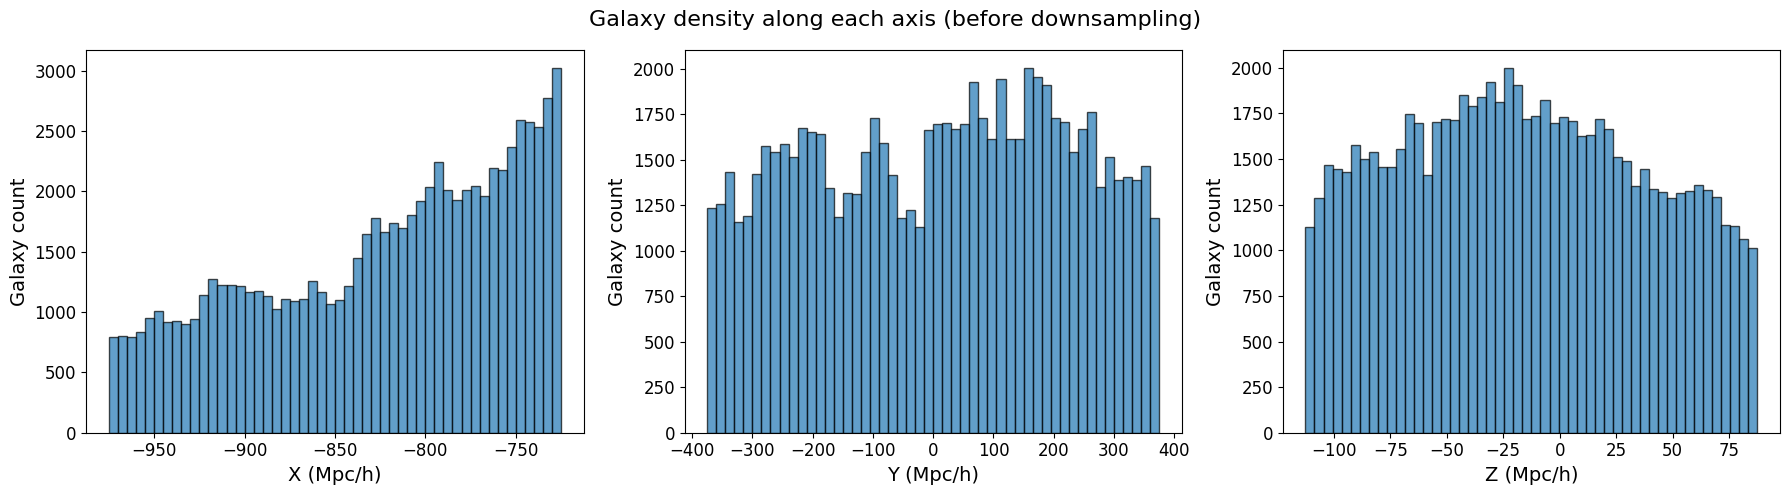

In [40]:
# Plot galaxy density as a function of X, Y, and Z
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axis_labels = ['X (Mpc/h)', 'Y (Mpc/h)', 'Z (Mpc/h)']

for i, (ax, label) in enumerate(zip(axes, axis_labels)):
    ax.hist(inner_positions[:, i], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel(label, fontsize=14)
    ax.set_ylabel('Galaxy count', fontsize=14)
    ax.tick_params(labelsize=12)

fig.suptitle('Galaxy density along each axis (before downsampling)', fontsize=16)
plt.tight_layout()
plt.show()

In [41]:
# Voxel-based downsampling to uniform density
voxel_size = 20  # Mpc/h per voxel side length

# Assign each outer galaxy to a voxel
voxel_indices = np.floor(outer_positions / voxel_size).astype(int)

# Create a unique key per voxel
voxel_keys = [tuple(v) for v in voxel_indices]

# Group galaxy indices by voxel
from collections import defaultdict
voxel_to_galaxies = defaultdict(list) # adds list as default value type
for i, key in enumerate(voxel_keys):
    voxel_to_galaxies[key].append(i)

# Find the minimum number of galaxies in any occupied voxel
counts = [len(gals) for gals in voxel_to_galaxies.values()]
target_count = int(np.percentile(counts, 10))  # use 10th percentile to avoid extremely sparse voxels
print(f"Voxel size: {voxel_size} Mpc/h")
print(f"Number of occupied voxels: {len(voxel_to_galaxies)}")
print(f"Galaxies per voxel: min={np.min(counts)}, median={int(np.median(counts))}, max={np.max(counts)}")
print(f"Target galaxies per voxel (10th percentile): {target_count}")

# Randomly subsample each voxel to the target count
keep_indices = []
for key, gal_indices in voxel_to_galaxies.items():
    if len(gal_indices) <= target_count:
        keep_indices.extend(gal_indices)
    else:
        keep_indices.extend(np.random.choice(gal_indices, size=target_count, replace=False))

keep_indices = np.sort(keep_indices)

# Update outer_positions
outer_positions = outer_positions[keep_indices]

# Recompute which of the subsampled outer galaxies fall in the inner box
inner_indices_in_outer = np.where(
    (outer_positions[:, 0] >= x_center - half_box_x) & (outer_positions[:, 0] < x_center + half_box_x) &
    (outer_positions[:, 1] >= y_center - half_box_y) & (outer_positions[:, 1] < y_center + half_box_y) &
    (outer_positions[:, 2] >= z_center - half_box_z) & (outer_positions[:, 2] < z_center + half_box_z)
)[0]

# Update inner_positions from the subsampled outer set
inner_positions = outer_positions[inner_indices_in_outer]

print(f"\nAfter downsampling:")
print(f"  Outer galaxies: {len(outer_positions)}")
print(f"  Inner galaxies: {len(inner_positions)}")

Voxel size: 20 Mpc/h
Number of occupied voxels: 6191
Galaxies per voxel: min=1, median=9, max=164
Target galaxies per voxel (10th percentile): 2

After downsampling:
  Outer galaxies: 11830
  Inner galaxies: 8889


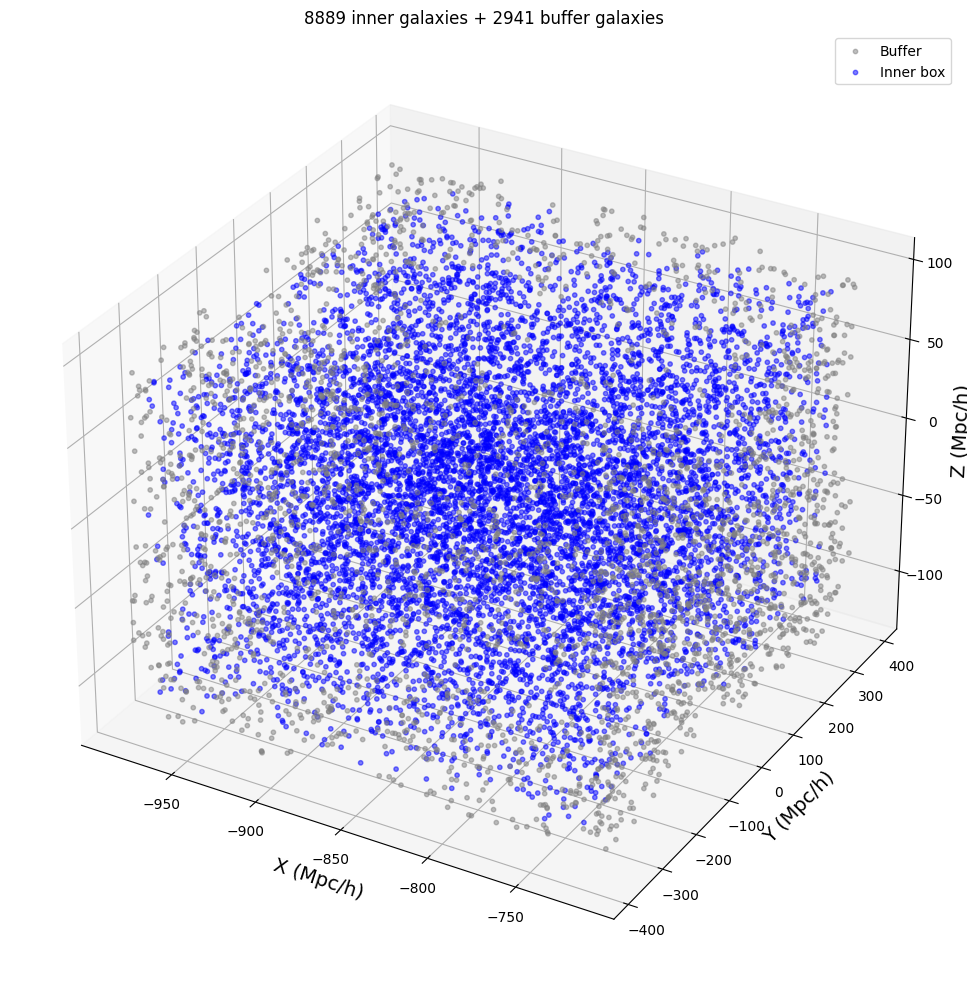

In [42]:
# Visualize the selected regions
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# Plot buffer galaxies in grey
buffer_mask = np.ones(len(outer_positions), dtype=bool)
buffer_mask[inner_indices_in_outer] = False
ax.scatter(outer_positions[buffer_mask, 0], outer_positions[buffer_mask, 1], 
           outer_positions[buffer_mask, 2], alpha=0.5, s=10, c='grey', label='Buffer')

# Plot inner galaxies in blue
ax.scatter(inner_positions[:, 0], inner_positions[:, 1], inner_positions[:, 2], 
           alpha=0.5, s=10, c='blue', label='Inner box')

ax.set_xlabel('X (Mpc/h)', fontsize=14)
ax.set_ylabel('Y (Mpc/h)', fontsize=14)
ax.set_zlabel('Z (Mpc/h)', fontsize=14)
ax.set_title(f'{len(inner_positions)} inner galaxies + {len(outer_positions) - len(inner_positions)} buffer galaxies')
ax.legend()
plt.tight_layout()
plt.show()

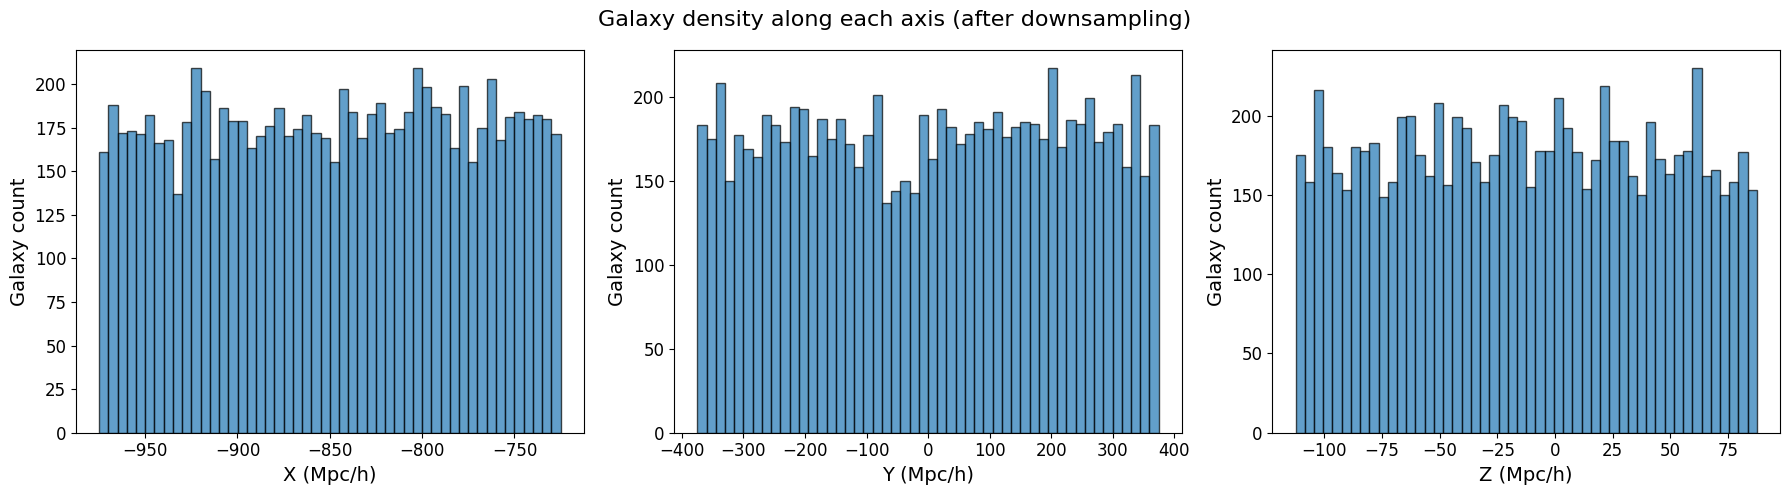

In [44]:
# Plot galaxy density as a function of X, Y, and Z
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axis_labels = ['X (Mpc/h)', 'Y (Mpc/h)', 'Z (Mpc/h)']

for i, (ax, label) in enumerate(zip(axes, axis_labels)):
    ax.hist(inner_positions[:, i], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel(label, fontsize=14)
    ax.set_ylabel('Galaxy count', fontsize=14)
    ax.tick_params(labelsize=12)

fig.suptitle('Galaxy density along each axis (after downsampling)', fontsize=16)
plt.tight_layout()
plt.show()

In [45]:
# Simple Euclidean distance matrix (no periodic boundary conditions)
def euclidean_distance_matrix(positions):
    """
    Calculate pairwise Euclidean distances between all points.
    
    Parameters:
        positions: array of shape (N, 3) with x, y, z coordinates
        
    Returns:
        dist_matrix: array of shape (N, N) with pairwise distances
    """
    return euclidean_distances(positions)

In [46]:
# Calculate the physical distance matrix for the OUTER region (includes buffer)
print(f"Calculating distance matrix for {len(outer_positions)} galaxies (including buffer)...")
start_time = time.time()
distance_matrix = euclidean_distance_matrix(outer_positions)
print(f"Distance matrix computed in {time.time() - start_time:.2f} seconds")
print(f"Distance matrix shape: {distance_matrix.shape}")

Calculating distance matrix for 11830 galaxies (including buffer)...
Distance matrix computed in 0.82 seconds
Distance matrix shape: (11830, 11830)


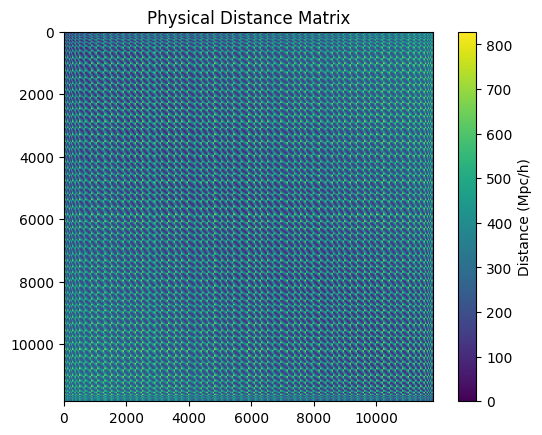

In [47]:
plt.imshow(distance_matrix, cmap='viridis')
plt.colorbar(label='Distance (Mpc/h)')
plt.title('Physical Distance Matrix')
plt.show()

In [48]:
# Set neighborhood threshold
threshold = buffer_size  # Mpc/h

# Create nearest neighbor matrix: keep distances < threshold, set others to 0
nearest_neighbor_matrix = np.where(distance_matrix < threshold, distance_matrix, 0)
print(f"Using neighborhood radius r = {threshold} Mpc/h")

Using neighborhood radius r = 10 Mpc/h


In [49]:
# Calculate similarity distances between sorted neighborhood distance vectors
print("Calculating similarity distances...")
start_time = time.time()
similarity_distances = euclidean_distances(np.sort(nearest_neighbor_matrix, axis=1))
print(f"Similarity distances computed in {time.time() - start_time:.2f} seconds")

Calculating similarity distances...
Similarity distances computed in 24.05 seconds


In [22]:
inner_indices_in_outer

array([  77,   89,  103, ..., 8358, 8360, 8366])

In [23]:
inner_indices_in_outer.shape, similarity_distances.shape

((6717,), (8434, 8434))

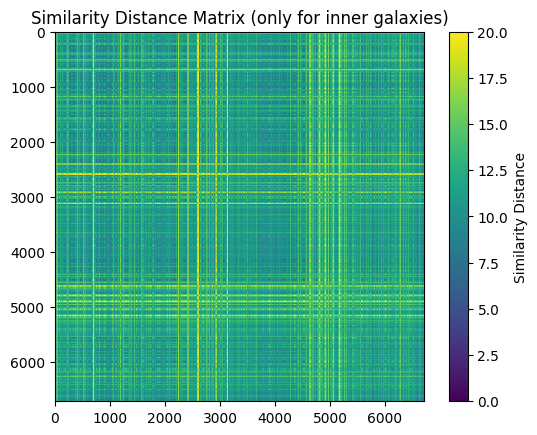

In [24]:
plt.imshow(similarity_distances[inner_indices_in_outer][:,inner_indices_in_outer], cmap='viridis', vmin=0,vmax=20)
plt.colorbar(label='Similarity Distance')
plt.title('Similarity Distance Matrix (only for inner galaxies)')
plt.show()

Computing eigendecomposition...
Eigendecomposition computed in 0.19 seconds


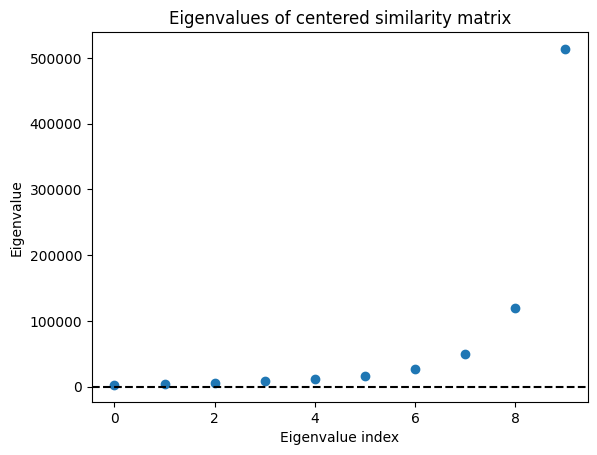

In [25]:
# MDS embedding
from scipy.sparse.linalg import eigsh

D = similarity_distances**2

num_points = D.shape[0]
C = np.eye(num_points) - (1 / num_points) * np.ones_like(D)
B = -0.5 * np.matmul(C, np.matmul(D, C))

print("Computing eigendecomposition...")
start_time = time.time()
evals, evecs = eigsh(B, k=10, which='LA')
print(f"Eigendecomposition computed in {time.time() - start_time:.2f} seconds")

plt.plot(evals, 'o')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Eigenvalue index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalues of centered similarity matrix')
plt.show()

In [26]:
# Sort eigenvalues from largest to smallest
order = np.argsort(evals)[::-1]
evals = evals[order]
evecs = evecs[:, order]

# Use leading positive eigenvalues
num_positive = 10
num_to_keep = max(2, num_positive)
print(f"Keeping {num_to_keep} dimensions")
X = evecs[:, :num_to_keep] * np.sqrt(evals[:num_to_keep])

# Extract only the embeddings for galaxies in the INNER box (discard buffer)
X_inner = X[inner_indices_in_outer, :]
embedding = X_inner[:, :3]

print(f"Full embedding shape: {X.shape}")
print(f"Inner embedding shape (excluding buffer): {embedding.shape}")

Keeping 10 dimensions
Full embedding shape: (8434, 10)
Inner embedding shape (excluding buffer): (6717, 3)


/var/folders/0r/_1bnthz146q2xj0c42f4nl_80000gq/T/ipykernel_51390/4236388956.py:41: MatplotlibDeprecationWarning: The draw_all function was deprecated in Matplotlib 3.6 and will be removed two minor releases later. Use fig.draw_without_rendering() instead.
  cbar.draw_all()


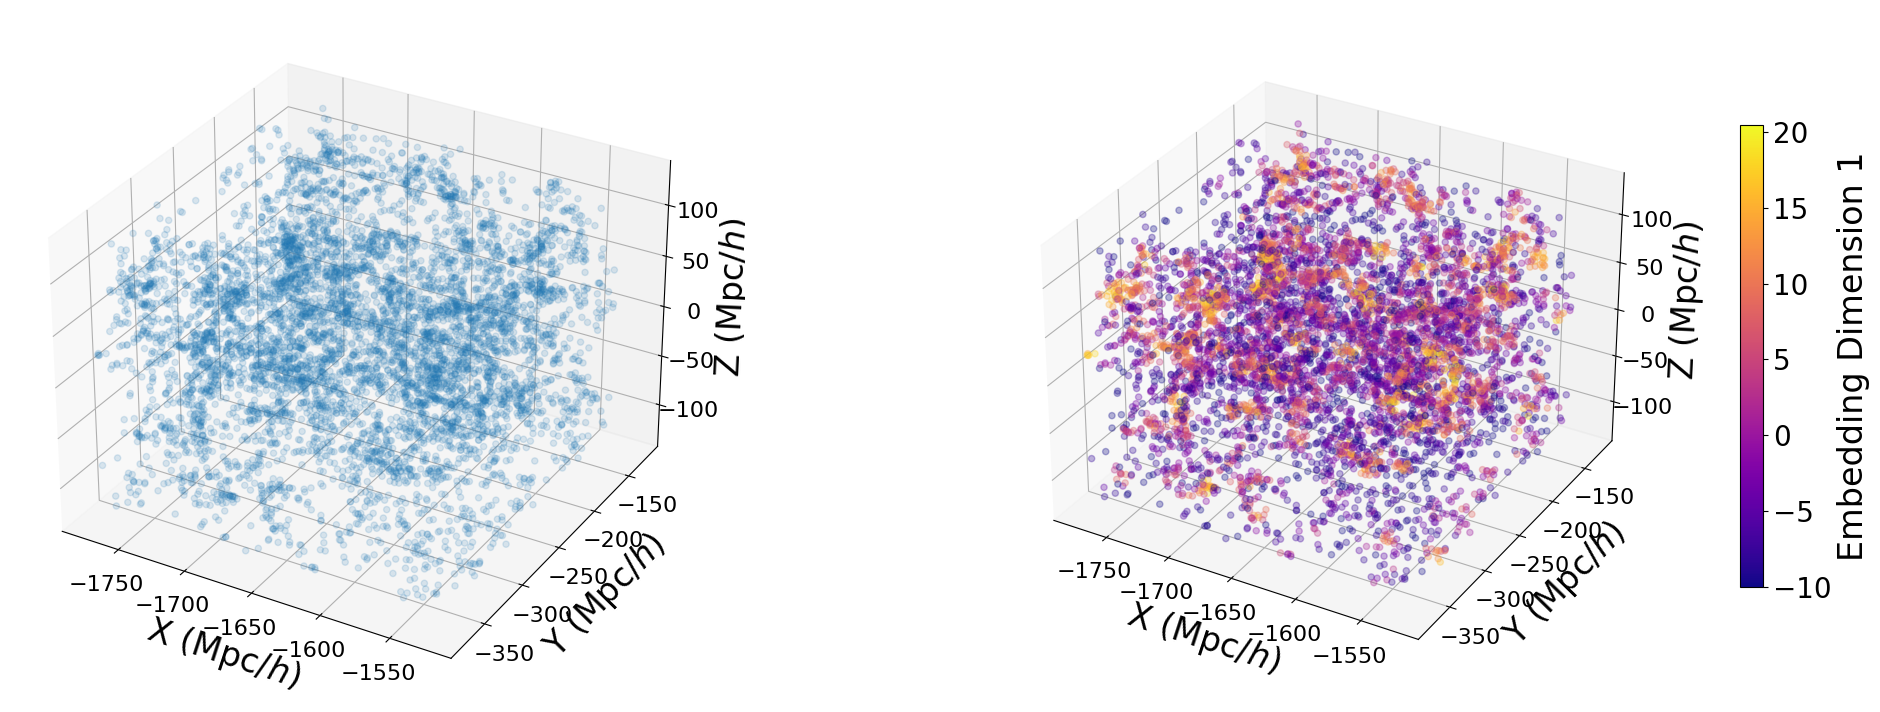

In [27]:
# Visualize embedding results (using inner_positions, not outer)
fig = plt.figure(figsize=(20, 10))
ax1 = plt.subplot(121, projection='3d')
p1 = ax1.scatter(inner_positions[:,0], 
                 inner_positions[:,1], 
                 inner_positions[:,2], alpha=0.15)

cbar = fig.colorbar(p1, ax=ax1, shrink=0.6)
cbar.ax.cla()
cbar.ax.set_alpha(0) 

# You might also need to set the alpha of the outline and ticks if present
cbar.outline.set_alpha(0)
for tick in cbar.ax.get_yticklines():
    tick.set_alpha(0)
for label in cbar.ax.get_yticklabels():
    label.set_alpha(0)
for label in cbar.ax.get_xticklabels():
    label.set_alpha(0)
for tick in cbar.ax.get_xticklines():
    tick.set_alpha(0)

ax1.set_xlabel('X (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.set_ylabel('Y (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.set_zlabel('Z (Mpc/$h$)', fontsize=24, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=16, pad=5)
ax1.tick_params(axis='both', which='minor', labelsize=16, pad=5)

ax = plt.subplot(122, projection='3d')

p = ax.scatter(inner_positions[:,0], 
               inner_positions[:,1], inner_positions[:,2], 
               c=embedding[:,0], alpha=0.3, cmap='plasma')
ax.set_xlabel('X (Mpc/$h$)', fontsize=24, labelpad=10)
ax.set_ylabel('Y (Mpc/$h$)', fontsize=24, labelpad=10)
ax.set_zlabel('Z (Mpc/$h$)', fontsize=24, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=16, pad=5)
ax.tick_params(axis='both', which='minor', labelsize=16, pad=5)
cbar = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1)
cbar.set_alpha(1)
cbar.draw_all()
cbar.set_label("Embedding Dimension 1", fontsize=24)
cbar.ax.tick_params(labelsize=20)

plt.subplots_adjust(left=0.05, right=0.98, wspace=0.15)
plt.show()

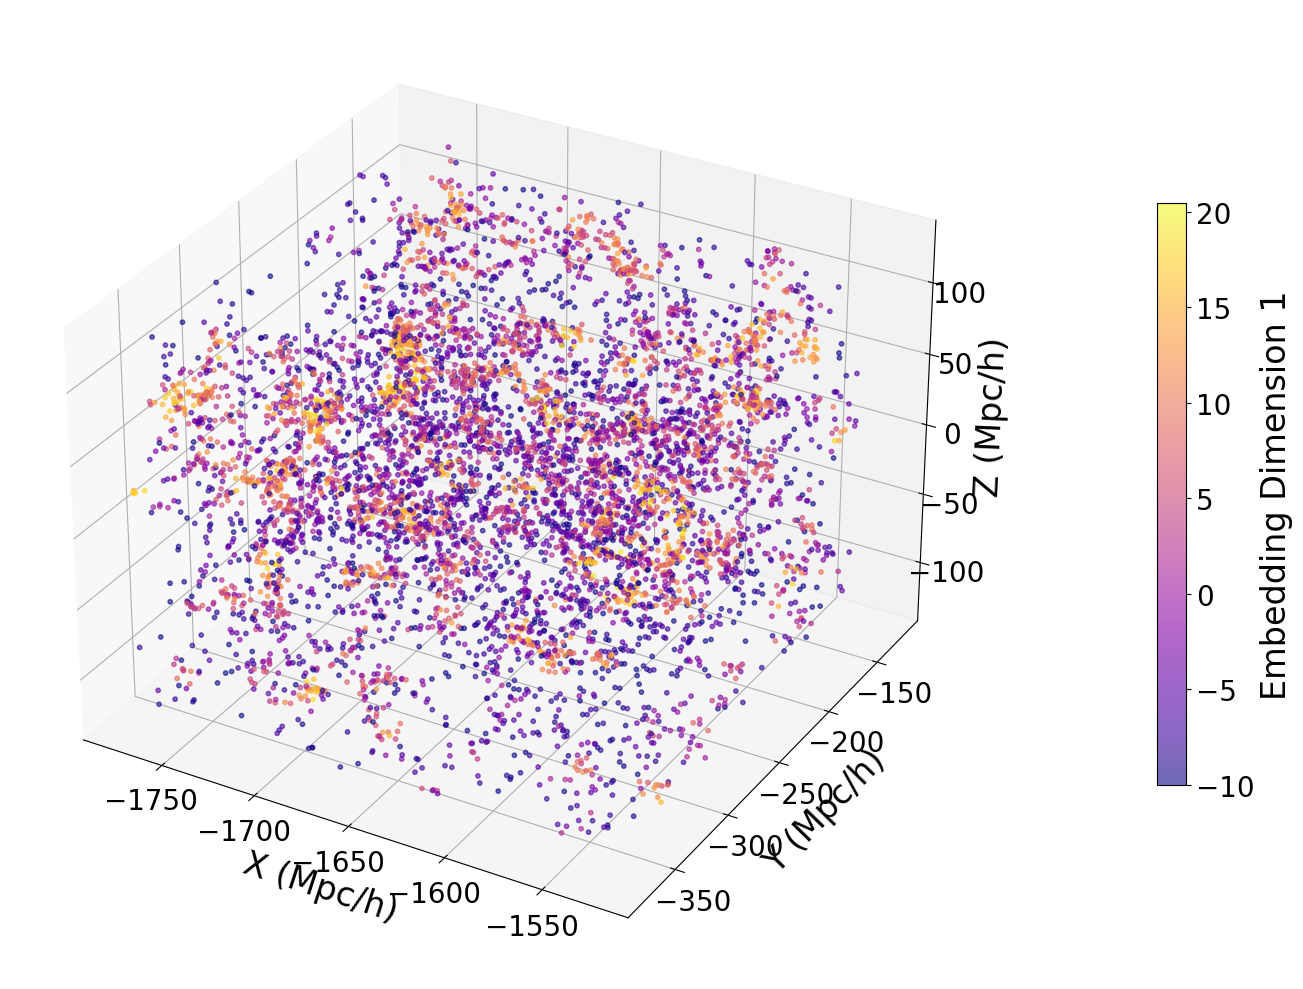

In [28]:
fig = plt.figure(figsize=(18, 10))

# Right: positions colored by first embedding dimension
ax = plt.subplot(111, projection='3d')
p = ax.scatter(inner_positions[:, 0], 
               inner_positions[:, 1], 
               inner_positions[:, 2], 
               c=embedding[:, 0], alpha=0.6, cmap='plasma', s=10)

ax.set_xlabel('X (Mpc/h)', fontsize=24, labelpad=10)
ax.set_ylabel('Y (Mpc/h)', fontsize=24, labelpad=10)
ax.set_zlabel('Z (Mpc/h)', fontsize=24, labelpad=8)
ax.tick_params(axis='both', which='major', labelsize=20)

cbar = fig.colorbar(p, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Embedding Dimension 1", fontsize=24)
cbar.ax.tick_params(labelsize=20)

plt.tight_layout()
plt.show()

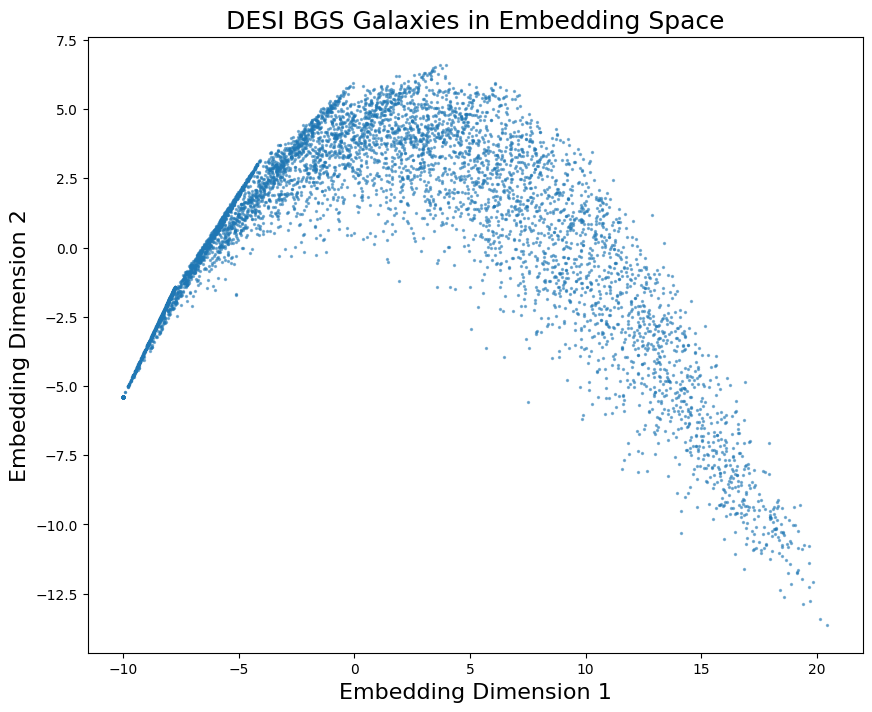

In [29]:
# 2D embedding space visualization
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=2, alpha=0.5)
plt.xlabel("Embedding Dimension 1", fontsize=16)
plt.ylabel("Embedding Dimension 2", fontsize=16)
plt.title("DESI BGS Galaxies in Embedding Space", fontsize=18)
plt.show()

In [30]:
# Interactive 3D visualization with plotly
import plotly.express as px

fig = px.scatter_3d(
    x=inner_positions[:, 0], 
    y=inner_positions[:, 1], 
    z=inner_positions[:, 2], 
    color=embedding[:, 0],
    color_continuous_scale='plasma',
    labels={'color': 'Embedding Dim 1'}
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=30),
    title='DESI LRG Galaxies colored by Embedding Dimension 1'
)

from plotly.offline import plot
plot(fig, filename='desi_galaxies_embedding.html', auto_open=True)
fig.show()

Text(0.5, 0.98, 'After subsampling')

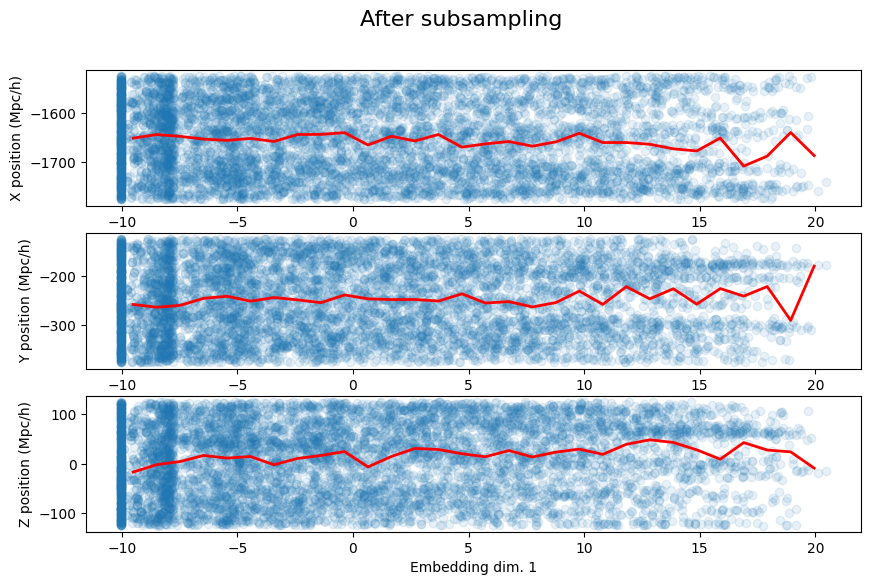

In [31]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6))

ax[0].plot( embedding[:, 0],inner_positions[:, 0],'o', alpha=0.1)
ax[0].set_ylabel('X position (Mpc/h)')
ax[0].set_xlabel('Embedding dim. 1')
# plot running median line
running_median, bin_edges, _ = binned_statistic(embedding[:, 0], 
                                                inner_positions[:, 0], 
                                                statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
ax[0].plot(bin_centers, running_median, color='red', linewidth=2, label="Running Median")

ax[1].plot(embedding[:, 0], inner_positions[:, 1], 'o', alpha=0.1)
ax[1].set_ylabel('Y position (Mpc/h)')
ax[1].set_xlabel('Embedding dim. 1')
running_median, bin_edges, _ = binned_statistic(embedding[:, 0], 
                                                inner_positions[:, 1], 
                                                statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
ax[1].plot(bin_centers, running_median, color='red', linewidth=2, label="Running Median")


ax[2].plot(embedding[:, 0], inner_positions[:, 2], 'o', alpha=0.1)
ax[2].set_xlabel('Embedding dim. 1')
ax[2].set_ylabel('Z position (Mpc/h)')
running_median, bin_edges, _ = binned_statistic(embedding[:, 0], 
                                                inner_positions[:, 2], 
                                                statistic='median', bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
ax[2].plot(bin_centers, running_median, color='red', linewidth=2, label="Running Median")

# plot title
fig.suptitle('After subsampling', fontsize=16)

In [32]:
# DBSCAN clustering for comparison (on inner positions only)
clustering = DBSCAN(eps=threshold, min_samples=5).fit(inner_positions)
print(f"Number of clusters found: {len(np.unique(clustering.labels_)) - 1}")  # -1 excludes noise label
print(f"Number of galaxies in clusters: {np.sum(clustering.labels_ >= 0)}")
print(f"Number of galaxies not in clusters: {np.sum(clustering.labels_ < 0)}")

Number of clusters found: 246
Number of galaxies in clusters: 4813
Number of galaxies not in clusters: 1904


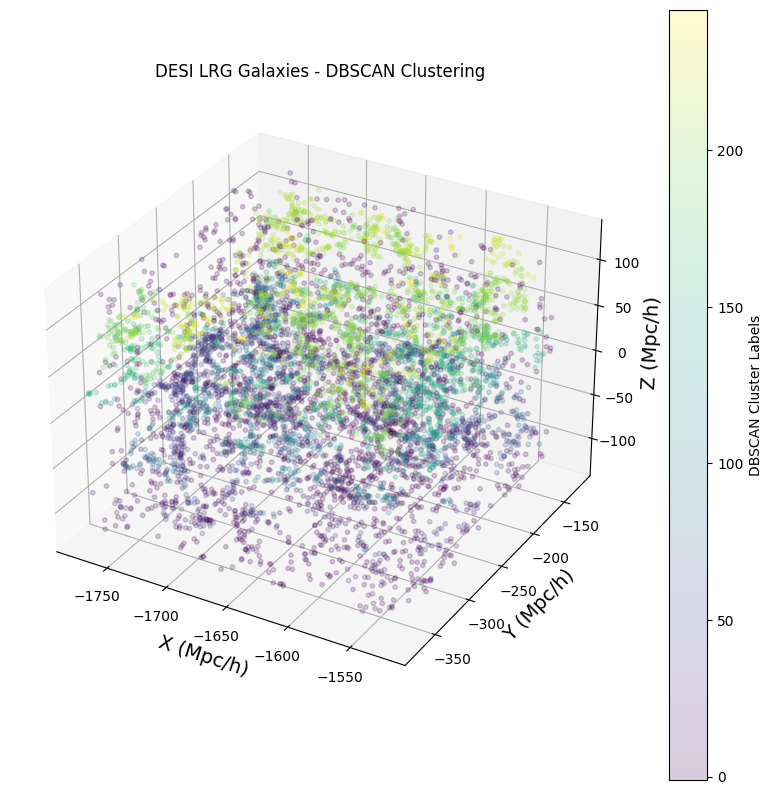

In [33]:
# Visualize DBSCAN clusters
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
p = ax.scatter(inner_positions[:, 0], 
               inner_positions[:, 1], 
               inner_positions[:, 2], 
               alpha=0.2, c=clustering.labels_, cmap='viridis', s=10)

ax.set_xlabel('X (Mpc/h)', fontsize=14)
ax.set_ylabel('Y (Mpc/h)', fontsize=14)
ax.set_zlabel('Z (Mpc/h)', fontsize=14)

cbar = fig.colorbar(p, ax=ax)
cbar.set_label("DBSCAN Cluster Labels")
plt.title("DESI LRG Galaxies - DBSCAN Clustering")
plt.show()

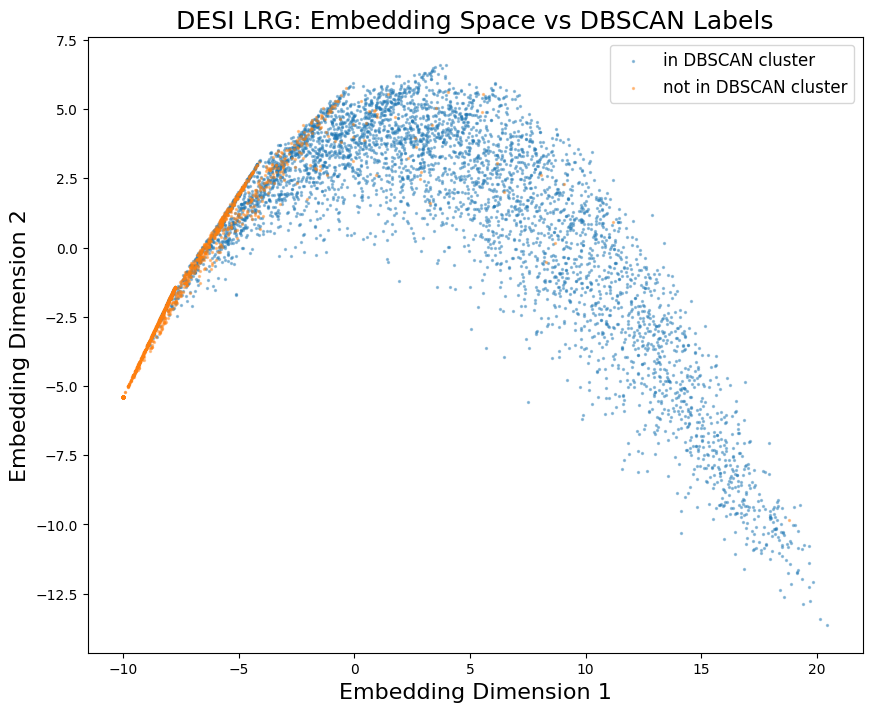

In [34]:
# Compare embedding with DBSCAN labels
plt.figure(figsize=(10, 8))
plt.scatter(embedding[clustering.labels_ >= 0, 0], 
            embedding[clustering.labels_ >= 0, 1], 
            s=2, alpha=0.4, label="in DBSCAN cluster")
plt.scatter(embedding[clustering.labels_ < 0, 0], 
            embedding[clustering.labels_ < 0, 1], 
            s=2, alpha=0.4, label="not in DBSCAN cluster")

plt.xlabel("Embedding Dimension 1", fontsize=16)
plt.ylabel("Embedding Dimension 2", fontsize=16)
plt.title("DESI LRG: Embedding Space vs DBSCAN Labels", fontsize=18)
plt.legend(fontsize=12)
plt.show()

In [31]:
# Save embeddings with TARGETIDs to a CSV file
import pandas as pd

# Get TARGETIDs for the inner galaxies
inner_targetids = data['TARGETID'][outer_mask][inner_indices_in_outer]

# Create a DataFrame with TARGETIDs and all embedding dimensions
embedding_df = pd.DataFrame({
    'TARGETID': inner_targetids,
    'embedding_1': embedding[:, 0],
    'embedding_2': embedding[:, 1],
    'embedding_3': embedding[:, 2],
})

# Save to CSV
output_filename = 'desi_bgs_embeddings_020226_subsampled.csv'
embedding_df.to_csv(output_filename, index=False)
print(f"Saved {len(embedding_df)} embeddings to {output_filename}")
print(embedding_df.head())

Saved 9437 embeddings to desi_bgs_embeddings_020226_subsampled.csv
            TARGETID  embedding_1  embedding_2  embedding_3
0  39627576670424492     5.086425     1.178780    -0.034560
1  39627576674619558     0.160928    -1.936141     0.253562
2  39627576724947009    -3.051086    -3.967443     0.441452
3  39627576787862921    -0.261137    -2.203058     0.278251
4  39627576842392398    -2.776169    -3.793583     0.425370
